Iniciando com uma regressão linear SEM aplicar nenhuma técnica de data augmentation.

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from imblearn.over_sampling import SMOTE


In [2]:
df = pd.read_csv('data/wsales.csv')

FEATURES_NUM = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
FEATURE_BIN = 'Holiday_Flag'
FEATURE_CAT = 'Store'

store_dummies = pd.get_dummies(df['Store'], prefix='Store', drop_first=True, dtype=float)

X = pd.concat([df[[FEATURE_BIN] + FEATURES_NUM], store_dummies], axis=1)
y = df['Weekly_Sales'].values

print(X.shape, y.shape)


(6435, 49) (6435,)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


In [4]:
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[FEATURES_NUM])
X_test_num = scaler.transform(X_test[FEATURES_NUM])

X_train_final = np.hstack([X_train[[FEATURE_BIN]].values, X_train_num, X_train[store_dummies.columns].values])
X_test_final = np.hstack([X_test[[FEATURE_BIN]].values, X_test_num, X_test[store_dummies.columns].values])


In [5]:
model = LinearRegression()
model.fit(X_train_final, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](49,)","[ 72763.84, -14503.67, -19532.38,..., -848745.18,-1000570.85, -656298.79]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.403e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,49
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(49)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](49,)","[83.39,77.42,71.94,..., 2.95, 2.36, 0.34]"


In [6]:
y_pred = model.predict(X_test_final)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MSE: {mse:.2f}')
print(f'MAE: {mae:.2f}')
print(f'R²: {r2:.4f}')


MSE: 25498969757.07
MAE: 91043.93
R²: 0.9208


Gráfico: predito vs real.

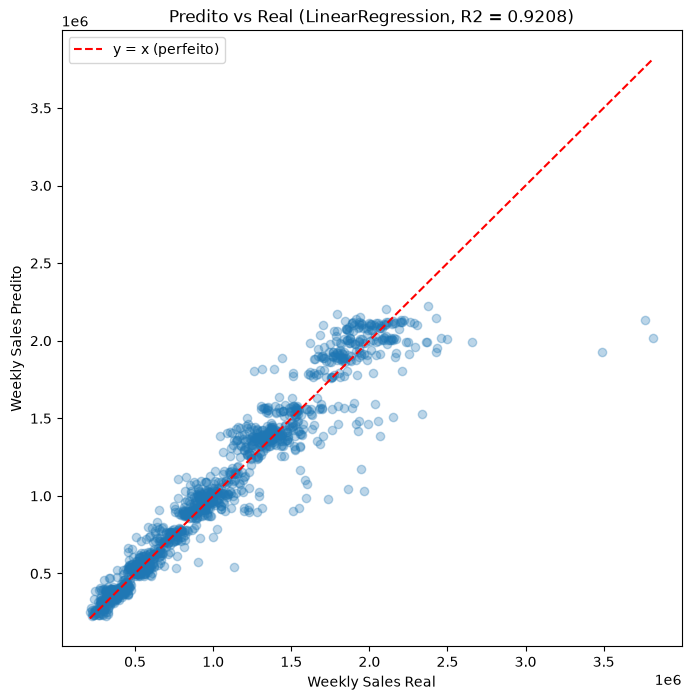

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', label='y = x (perfeito)')
plt.xlabel('Weekly Sales Real')
plt.ylabel('Weekly Sales Predito')
plt.title(f'Predito vs Real (LinearRegression, R2 = {r2_score(y_test, y_pred):.4f})')
plt.legend()
plt.show()


Inserir SMOTE
=============================================

1. Discretizar o alvo em classes (bins de largura igual; a cauda rara é fundida para o SMOTE funcionar).

In [8]:
edges = np.linspace(y.min(), y.max(), 11)
y_class = np.clip(np.digitize(y, edges) - 1, 0, 9).astype(int)

y_class[y_class == 7] = 6
y_class[y_class == 8] = 7
y_class[y_class == 9] = 7

print('Contagem por classe (0-7):', np.bincount(y_class))


Contagem por classe (0-7): [1697 1367 1270 1049  668  314   58   12]


2. Máscara assimétrica: SMOTE apenas nas classes raras (vendas altas).

In [9]:
mask = y_class >= 5
mask_middle = ~mask
print('Na máscara (altas):', mask.sum(), '| meio:', mask_middle.sum())


Na máscara (altas): 384 | meio: 6051


3. Aplicar SMOTE com as features padronizadas (para a distância não ser dominada por CPI).

In [10]:
smote = SMOTE(k_neighbors=3, random_state=42)

scaler_smote = StandardScaler()
X_mask_scaled = scaler_smote.fit_transform(X.values[mask])
X_smote_scaled, y_class_smote = smote.fit_resample(X_mask_scaled, y_class[mask])
X_smote = scaler_smote.inverse_transform(X_smote_scaled)
print('X_smote:', X_smote.shape, '(antes:', X.values[mask].shape, ')')


X_smote: (942, 49) (antes: (384, 49) )


4. Definir o alvo das sintéticas por interpolação local (kNN ponderado por distância).

In [11]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=3, weights='distance')
knn.fit(X_mask_scaled, y[mask])
y_smote = knn.predict(X_smote_scaled)

orig_scaled_by_hash = {}
for i in range(len(X_mask_scaled)):
    h = X_mask_scaled[i].tobytes()
    if h not in orig_scaled_by_hash:
        orig_scaled_by_hash[h] = y[mask][i]
y_smote = np.array([
    orig_scaled_by_hash.get(r.tobytes(), v) for r, v in zip(X_smote_scaled, y_smote)
])


5. Combinar com as originais do meio.

In [12]:
X_final = np.vstack([X_smote, X.values[mask_middle]])
y_final = np.hstack([y_smote, y[mask_middle]])
y_final_class = np.hstack([y_class_smote, y_class[mask_middle]]).astype(int)
print('X_final:', X_final.shape, '| y_final:', y_final.shape)


X_final: (6993, 49) | y_final: (6993,)


In [14]:
X_final


array([[ 0.   , 52.33 ,  2.886, ...,  0.   ,  0.   ,  0.   ],
       [ 1.   , 60.14 ,  3.236, ...,  0.   ,  0.   ,  0.   ],
       [ 0.   , 47.96 ,  3.112, ...,  0.   ,  0.   ,  0.   ],
       ...,
       [ 0.   , 54.47 ,  4.   , ...,  0.   ,  0.   ,  1.   ],
       [ 0.   , 56.47 ,  3.969, ...,  0.   ,  0.   ,  1.   ],
       [ 0.   , 58.85 ,  3.882, ...,  0.   ,  0.   ,  1.   ]],
      shape=(6993, 49))

6. Re-divisão em treino/teste.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2, random_state=42)
print('Treino:', X_train.shape, '| Teste:', X_test.shape)


Treino: (5594, 49) | Teste: (1399, 49)


7. Re-escalonar e treinar.

In [16]:
X_train_num = scaler.fit_transform(X_train[:, 1:5])
X_test_num = scaler.transform(X_test[:, 1:5])
X_train_final = np.hstack([X_train[:, [0]], X_train_num, X_train[:, 5:]])
X_test_final = np.hstack([X_test[:, [0]], X_test_num, X_test[:, 5:]])
print('Treino final:', X_train_final.shape, '| Teste final:', X_test_final.shape)


Treino final: (5594, 49) | Teste final: (1399, 49)


In [17]:
model.fit(X_train_final, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](49,)","[ 27884.72, -78968.1 , -36020.61,...,-851830.83,-996951.16,-674504.61]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.419e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,49
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(49)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](49,)","[85.93,81.66,74.87,..., 3.02, 2.47, 0.35]"


8. Avaliar.

In [18]:
y_pred = model.predict(X_test_final)
print(f'MSE: {mean_squared_error(y_test, y_pred):.2f}')
print(f'MAE: {mean_absolute_error(y_test, y_pred):.2f}')
print(f'R2: {r2_score(y_test, y_pred):.4f}')


MSE: 53188561885.87
MAE: 156138.27
R2: 0.9000


Inserir Mix-Up
===============

1. Função MixUp.

In [19]:
def mixup(X, y, alpha=0.2, n_samples=2):
    X_mix = []
    y_mix = []

    for _ in range(n_samples):
        indices = np.arange(len(X))
        np.random.shuffle(indices)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        lam = np.random.beta(alpha, alpha)

        X_mixed = lam * X + (1 - lam) * X_shuffled
        y_mixed = lam * y + (1 - lam) * y_shuffled

        X_mix.append(X_mixed)
        y_mix.append(y_mixed)

    return np.vstack(X_mix), np.hstack(y_mix)


2. Aplicar MixUp dentro de cada grupo de classe.

In [20]:
X_mix = []
y_mix = []
cls_mix = []

for c in np.unique(y_final_class):
    X_group = X_final[y_final_class == c]
    y_group = y_final[y_final_class == c]

    X_mixed, y_mixed = mixup(X_group, y_group)

    X_mix.append(X_mixed)
    y_mix.append(y_mixed)
    cls_mix.append(np.full(len(X_mixed), c))

X_combined = np.vstack(X_mix)
y_combined = np.hstack(y_mix)
y_combined_class = np.hstack(cls_mix).astype(int)
print('X_combined:', X_combined.shape, '| y_combined:', y_combined.shape)


X_combined: (13986, 49) | y_combined: (13986,)


In [22]:
X_combined


array([[ 0.        , 45.70996608,  2.57200077, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.99999832, 47.92998791,  2.54800183, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        , 47.07002146,  2.51400096, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.        , 42.6028178 ,  2.88402383, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        , 48.33873885,  2.99732697, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        , 41.05803671,  2.87653244, ...,  0.        ,
         0.        ,  0.        ]], shape=(13986, 49))

3. Re-divisão em treino/teste.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X_combined, y_combined, test_size=0.2, random_state=42)
print('Treino:', X_train.shape, '| Teste:', X_test.shape)


Treino: (11188, 49) | Teste: (2798, 49)


4. Re-escalonar e treinar.

In [24]:
X_train_num = scaler.fit_transform(X_train[:, 1:5])
X_test_num = scaler.transform(X_test[:, 1:5])
X_train_final = np.hstack([X_train[:, [0]], X_train_num, X_train[:, 5:]])
X_test_final = np.hstack([X_test[:, [0]], X_test_num, X_test[:, 5:]])
print('Treino final:', X_train_final.shape, '| Teste final:', X_test_final.shape)


Treino final: (11188, 49) | Teste final: (2798, 49)


In [25]:
model.fit(X_train_final, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](49,)","[ 23008.16, -83369.04, -38543.4 ,...,-851294.14,-993900.5 ,-674555.64]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.419e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,49
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(49)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](49,)","[120.86,115.11,105.96,..., 4.1 , 3.4 , 0.48]"


5. Avaliar.

In [26]:
y_pred = model.predict(X_test_final)
print(f'MSE: {mean_squared_error(y_test, y_pred):.2f}')
print(f'MAE: {mean_absolute_error(y_test, y_pred):.2f}')
print(f'R2: {r2_score(y_test, y_pred):.4f}')


MSE: 55388272649.10
MAE: 156467.48
R2: 0.8909


Inserir ruído gaussiano
=======================

1. Função para adicionar ruído gaussiano.

In [27]:
def add_gaussian_noise(X, mean=0, stddev=0.1):
    noise = np.random.normal(mean, stddev, X.shape)
    return X + noise


2. Aplicar ruído apenas nas colunas contínuas (σ = 10% do desvio padrão de cada feature).

In [28]:
X_noisy = []
y_noisy = []

sigma_feat = X_combined[:, 1:5].std(axis=0) * 0.10

for c in np.unique(y_combined_class):
    idx = y_combined_class == c
    X_group = X_combined[idx].copy()
    y_group = y_combined[idx]

    X_group[:, 1:5] = add_gaussian_noise(X_group[:, 1:5], stddev=sigma_feat)

    X_noisy.append(X_group)
    y_noisy.append(y_group)

X_final_noisy = np.vstack([X_combined] + X_noisy)
y_final_noisy = np.hstack([y_combined] + y_noisy)
print('X_final_noisy:', X_final_noisy.shape, '| y_final_noisy:', y_final_noisy.shape)


X_final_noisy: (27972, 49) | y_final_noisy: (27972,)


In [29]:
X_final_noisy


array([[ 0.        , 45.70996608,  2.57200077, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.99999832, 47.92998791,  2.54800183, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        , 47.07002146,  2.51400096, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.        , 45.47785244,  2.87561447, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        , 47.89600045,  3.00707594, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        , 39.95964299,  2.91460336, ...,  0.        ,
         0.        ,  0.        ]], shape=(27972, 49))

3. Re-divisão em treino/teste.

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X_final_noisy, y_final_noisy, test_size=0.2, random_state=42)
print('Treino:', X_train.shape, '| Teste:', X_test.shape)


Treino: (22377, 49) | Teste: (5595, 49)


4. Re-escalonar e treinar.

In [31]:
X_train_num = scaler.fit_transform(X_train[:, 1:5])
X_test_num = scaler.transform(X_test[:, 1:5])
X_train_final = np.hstack([X_train[:, [0]], X_train_num, X_train[:, 5:]])
X_test_final = np.hstack([X_test[:, [0]], X_test_num, X_test[:, 5:]])
print('Treino final:', X_train_final.shape, '| Teste final:', X_test_final.shape)


Treino final:

 (22377, 49) | Teste final: (5595, 49)


In [32]:
model.fit(X_train_final, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](49,)","[ 27682.56, -81173.67, -28911.75,..., -860485.54,-1234419.58, -758720.65]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.537e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,49
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(49)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](49,)","[170.51,162.6 ,150.54,..., 5.96, 4.93, 1.15]"


5. Avaliar.

In [33]:
y_pred = model.predict(X_test_final)
print(f'MSE: {mean_squared_error(y_test, y_pred):.2f}')
print(f'MAE: {mean_absolute_error(y_test, y_pred):.2f}')
print(f'R2: {r2_score(y_test, y_pred):.4f}')


MSE: 58555941594.78
MAE: 161712.73
R2: 0.8868
